In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1- Load dataset
df_stream = pd.read_csv('streamworks_user_data.csv')
df_stream.head()
df_stream.info()
df_stream.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   str    
 3   signup_date           1498 non-null   str    
 4   last_active_date      1498 non-null   str    
 5   country               1497 non-null   str    
 6   subscription_type     1497 non-null   str    
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   str    
 11  referred_by_friend    1497 non-null   str    
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), str(7)
memory usage: 164.2 KB


,user_id,age,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee
count,1498.000000,1497.000000,1496.000000,1498.000000,1497.000000,1499.000000,1355.000000
mean,1750.871829,43.738811,39.903342,51.414419,2.498330,0.234156,10.180406
std,433.060980,15.083920,22.978288,28.580117,1.706829,0.423612,3.310705
min,1001.000000,18.000000,0.500000,0.000000,0.000000,0.000000,5.990000
25%,1376.250000,31.000000,19.450000,27.100000,1.000000,0.000000,5.990000
50%,1750.500000,44.000000,40.300000,52.700000,2.000000,0.000000,9.990000
75%,2125.750000,56.000000,59.800000,76.200000,4.000000,0.000000,13.990000
max,2500.000000,69.000000,79.900000,100.000000,5.000000,1.000000,14.990000


In [20]:
# 2. Clean dataset
# 2.1 columns list
df_stream.columns.tolist()
# 2.2 Check for missing values
df_stream.isnull().sum()
# 2.3 Check for duplicates
df_stream.duplicated().sum()
#2.4 handle date and time
df_stream['signup_date'] = pd.to_datetime(df_stream['signup_date'], format = '%d-%m-%y')
df_stream['last_active_date'] = pd.to_datetime(df_stream['last_active_date'], format = '%d-%m-%y')


In [11]:
# 2.5 handle missing values
df_stream.fillna({
    'age': df_stream['age'].mean(),
    'average_watch_hours': df_stream['average_watch_hours'].mean(),
    'subscription_type': df_stream['subscription_type'].mode()[0],
    'mobile_app_usage_pct': df_stream['mobile_app_usage_pct'].mean(),
}, inplace=True)
df_stream['gender'] = df_stream['gender'].fillna(df_stream['gender'].mode()[0])
df_stream['country'] = df_stream['country'].fillna(df_stream['country'].mode()[0])
df_stream['complaints_raised'] = df_stream['complaints_raised'].fillna(0)
df_stream = df_stream.dropna(subset=['user_id', 'signup_date', 'last_active_date'])
df_stream.isnull().sum()


user_id                   0
age                       0
gender                    0
signup_date               0
last_active_date          0
country                   0
subscription_type         0
average_watch_hours       0
mobile_app_usage_pct      0
complaints_raised         0
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
dtype: int64

In [21]:
# 3. create new features : tenure_days, watch_hours_per_fee_ratio, is_loyal, heavy_mobile_user
# 3.1 tenure_days = date between sign_up and last_active_date
df_stream['tenure_days'] = (df_stream['last_active_date'] - df_stream['signup_date']).dt.days
# 3.2 watch_hours_per_fee_ratio = average_watch_hours / monthly_fee
df_stream['watch_hours_per_fee_ratio'] = df_stream['average_watch_hours'] / (df_stream['monthly_fee'] + 1)  # Adding 1 to avoid division by zero
# 3.3 is_loyal = True if tenure_days > 180, else False
df_stream['is_loyal'] = df_stream['tenure_days'] > 180
# 3.4 heavy_mobile_user = True if mobile_app_usage_pct > median(mobile_app_usage_pct), else False
df_stream['heavy_mobile_user'] = df_stream['mobile_app_usage_pct'] > df_stream['mobile_app_usage_pct'].median()
# read new dataset
df_stream = pd.read_csv('streamworks_user_data.csv')
df_stream.head(10)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99
5,1006.0,25.0,Male,25-06-23,13-07-25,USA,Premium,40.0,24.7,1.0,No,Yes,0.0,13.99
6,1007.0,38.0,Male,15-02-23,13-07-25,UK,Premium,57.8,83.9,0.0,No,Yes,0.0,14.99
7,1008.0,56.0,Male,20-12-22,13-07-25,Germany,Premium,9.0,35.6,5.0,No,Yes,0.0,14.99
8,1009.0,36.0,Other,30-05-25,13-07-25,UK,Standard,11.6,82.7,1.0,No,Yes,0.0,NaN
9,1010.0,40.0,Male,07-11-24,13-07-25,France,Basic,21.5,70.9,5.0,Yes,Yes,0.0,6.99


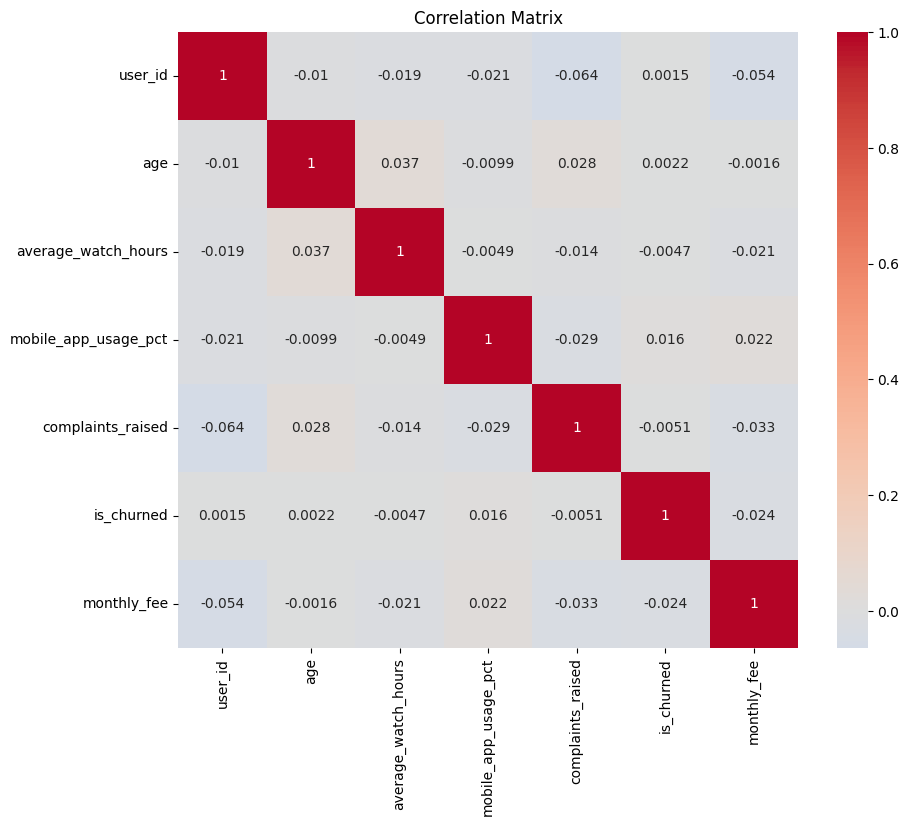

In [ ]:
# 4. Create a heatmap and correlation matrix
numeric_cols = df_stream.select_dtypes(include=[np.number]).columns
correlation_matrix = df_stream[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

